# Estudio de los avistamientos de aerostatos chinos sobre Estados Unidos

[Enlace a la noticia](https://www.revistaejercitos.com/focus/conflictos/el-globo-espia-chino-y-las-aplicaciones-militares-de-los-aerostatos/)

## Objetivos de la Práctica
- Realizar una carga y exploración estructural completa.
- Aplicar técnicas de limpieza e imputación estadística robusta.
- Detectar y analizar valores atípicos (outliers) que distorsionan la realidad.
- Realizar ingeniería de características para evaluar el peligro potencial.
- Validar la relación entre variables mediante matrices de correlación evolutivas.
- Construir y validar un modelo de Regresión Lineal.

In [35]:
# Librerías
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression

## Fase 1: Observar y Limpiar el Escenario (EDA Estructural)
### 1. Carga y Magnitud:
Importa el archivo avistamientos_aerostatos.csv (basado en los datos de Avistamiento.pdf). Muestra las dimensiones del dataset y realiza una inspección visual de las primeras y últimas 5 filas.

In [36]:
# Importa el dataset
df = pd.read_csv('avistamientos_aerostatos.csv')

# Muestra las primeras y últimas entradas del DataFrame
print("5 primeras filas:")
display(df.head())
print("5 últimas filas:")
display(df.tail())

# Muestra las dimensiones del DataFrame
print("Número de registros:", df.ID_Registro.size)
print("Número total de datos:", df.size)

# Muestra el tipo de dato de cada columna
print("Tipos de dato por columna")
display(df.dtypes)

5 primeras filas:


,ID_Registro,Pais_Origen,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Tecnologia_Detectada,Cercania_Base_Militar_km,Fecha_Avistamiento,Indice_Maniobra
0,REG-1000,EE.UU.,150.00,76.1,82.6,Vigilancia Radar,35.40,2023-02-07,49.38
1,REG-1001,Desconocido,0.50,10.4,94.1,Inteligencia de Señales,103.66,2023-01-31,21.20
2,REG-1002,EE.UU.,25.24,5000.0,39.2,Vigilancia Radar,34.02,2023-01-31,63.00
3,REG-1003,China,29.62,23.0,12.3,Meteorológico,60.58,2023-01-02,96.11
4,REG-1004,Rusia,20.83,26.7,19.0,Meteorológico,246.80,2023-02-06,101.54


5 últimas filas:


,ID_Registro,Pais_Origen,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Tecnologia_Detectada,Cercania_Base_Militar_km,Fecha_Avistamiento,Indice_Maniobra
505,REG-1005,EE.UU.,20.83,41.5,116.5,Inteligencia de Señales,7.05,2023-01-17,22.01
506,REG-1006,EE.UU.,29.90,19.4,42.5,Vigilancia Radar,16.06,2023-01-08,67.12
507,REG-1007,China,25.84,33.0,94.6,Vigilancia Radar,25.09,2023-01-09,33.77
508,REG-1008,Rusia,19.65,18.0,78.7,Inteligencia de Señales,27.39,2023-02-27,32.41
509,REG-1009,China,24.71,24.7,52.0,Meteorológico,26.47,2023-01-29,69.65


Número de registros: 510
Número total de datos: 4590
Tipos de dato por columna


ID_Registro                  object
Pais_Origen                  object
Altitud_km                  float64
Duracion_Vuelo_h            float64
Velocidad_Viento_kmh        float64
Tecnologia_Detectada         object
Cercania_Base_Militar_km    float64
Fecha_Avistamiento           object
Indice_Maniobra             float64
dtype: object

### 2. Forense de Datos:
Identifica y elimina registros duplicados.

In [37]:
print("Número de valores ausentes por columna")
display(df.isnull().sum())
print("Número de entradas duplicadas:", df.duplicated().sum())

# Elimina las entradas duplicadas
df = df.drop_duplicates()
print("Número de entradas duplicadas tras la eliminación:", df.duplicated().sum())

Número de valores ausentes por columna


ID_Registro                  0
Pais_Origen                  0
Altitud_km                  40
Duracion_Vuelo_h             0
Velocidad_Viento_kmh         0
Tecnologia_Detectada        40
Cercania_Base_Militar_km     0
Fecha_Avistamiento           0
Indice_Maniobra              0
dtype: int64

Número de entradas duplicadas: 10
Número de entradas duplicadas tras la eliminación: 0


### 3. Testigos Silenciosos:
Detecta valores nulos. Aplica una imputación estadística:
   - Rellena la Altitud_km con la mediana (para evitar el sesgo de valores extremos).
   - Rellena la Tecnologia_Detectada con la moda.

In [38]:
# Rellena los 40 valores nulos de altitud con la mediana
mediana_altitud = df.Altitud_km.median()            # Obtiene la mediana de las altitudes
moda_tecnologias = df.Tecnologia_Detectada.mode()   # Obtiene la moda de las tecnologías
df.Altitud_km = df.Altitud_km.fillna(mediana_altitud)
# Relleno con el primer elemento (y en este caso el único) que devuelve mode() (devuelve una lista)
df.Tecnologia_Detectada = df.Tecnologia_Detectada.fillna(moda_tecnologias[0])
print("Comprobación de nulos tras el relleno:")
display(df.isnull().sum())

Comprobación de nulos tras el relleno:


ID_Registro                 0
Pais_Origen                 0
Altitud_km                  0
Duracion_Vuelo_h            0
Velocidad_Viento_kmh        0
Tecnologia_Detectada        0
Cercania_Base_Militar_km    0
Fecha_Avistamiento          0
Indice_Maniobra             0
dtype: int64

## Fase 2: Perfilado y Detección de Anomalías
### 4. Resumen Estadístico:
Genera el perfil cuantitativo con .describe().

In [39]:
# Muestra un resumen estadístico
print("Resumen estadístico")
display(df.describe())

Resumen estadístico


,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Cercania_Base_Militar_km,Indice_Maniobra
count,500.000000,500.000000,500.00000,500.000000,500.000000
mean,22.240520,58.833600,65.54480,50.472620,54.394560
std,7.438844,223.929538,31.49662,50.565344,23.241086
min,0.500000,1.500000,10.40000,0.010000,3.480000
25%,18.770000,24.700000,38.35000,15.812500,34.905000
50%,22.090000,41.650000,66.95000,33.500000,53.790000
75%,24.997500,63.700000,93.12500,70.627500,72.625000
max,150.000000,5000.000000,119.80000,306.440000,116.620000


A simple vista con estas medidas de posición ya podemos observar dos valores extraños:
- Una altitud máxima de 150 kilómetros.
- Un vuelo de 5000 horas de duración.

### 5. Análisis de Distribución:
Calcula la asimetría (skew) y la curtosis de la variable Altitud_km. Explica por qué un valor de curtosis muy elevado (ej. > 170) indica la presencia de outliers severos.

In [40]:
# Calcula la asimetría y curtosis de Altitud_km
asimetria_altitud = df.Altitud_km.skew()
curtosis_altitud = df.Altitud_km.kurt()
print("Asimetría de Altitud_km:", asimetria_altitud)
print("Curtosis de Altitud_km:", curtosis_altitud)

Asimetría de Altitud_km: 10.126525848553973
Curtosis de Altitud_km: 174.09591265616945


La asimetría muestra **sesgo a la derecha de la media** (es superior a 0). Esto significa que la mayoría de las altitudes se concentran en torno a 10 kilómetros por encima de la media.

La curtosis positiva extremadamente alta indica que **algún valor atípico está generando una cola derecha en la distribución**. Probablemente sea el valor de 150 km observado antes.

Consecuencias: La distribución muestra una **forma asimétrica sesgada a la derecha de la media y con una gran cola derecha** que la hace leptocúrtica. Por tanto, **la media no es representativa del centro de los datos y el elevado valor de curtosis es una señal inequívoca de la presencia de outliers a la derecha**.

Conclusiones:
- Presencia de anomalías. Puede haber dos motivos:
   - Errores de medición.
   - Eventos excepcionales.

Se han rellenado los valores ausentes de altitud con la mediana en vez de la media, ya que la media no es representativa del centro de la muestra (hay sesgo a la derecha) y por tanto la mediana altera menos las medidas de posición.

### 6. Caza de Outliers:
Utiliza el método del Rango Intercuartílico (IQR) para identificar registros "imposibles" en la altitud y visualízalos mediante un Boxplot.

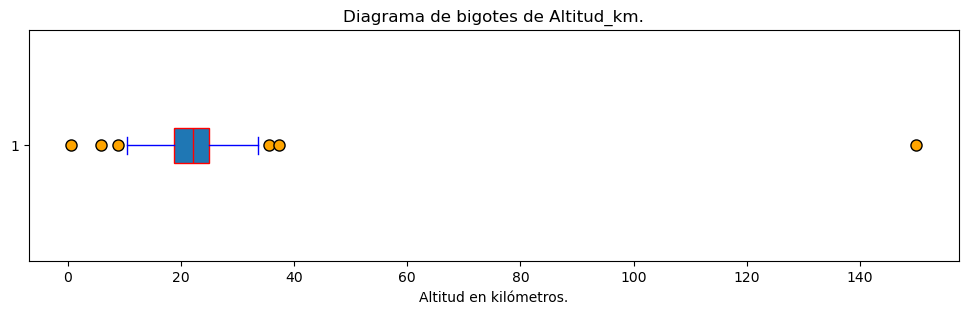

In [41]:
# Genera un diagrama de bigotes para ver outliers en Altitud_km
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html
fig1, ax1 = plt.subplots(figsize=(12, 3))   # Marco de 12x3 pulgadas

ax1.boxplot(df.Altitud_km,                      # Boxplot de Altitud_km
            vert=False,                         # Horizontal
            patch_artist=True,                  # Interior de la caja IQR azul
            boxprops=dict(color='red'),         # Bordes de la caja IQR rojos
            medianprops=dict(color='red'),      # Mediana roja
            whiskerprops=dict(color='blue'),    # Bigotes azules
            capprops=dict(color='blue'),        # Extremos de los bigotes azules
            flierprops=dict(markerfacecolor='orange', markersize=8))    # Estilo de los outliers

plt.title("Diagrama de bigotes de Altitud_km.")
plt.xlabel("Altitud en kilómetros.")

plt.show()

El outlier del extremo derecho del diagrama tiene un valor de 150 km. Este valor deforma toda la muestra y se hace necesario investigar la posibilidad de que sea producto de un error de de medición.

Investigando sobre la altitud máxima que podría alcanzar un aerostato, hay que distinguir entre dos tipos de aerostatos:
- De aire caliente: El récord de altura registrado es de aproximadamente 20 km.
   - [Fuente](https://seattleballooning.com/how-high-can-hot-air-balloons-fly/)
- De helio/hidrógeno: Algunos vuelos han superado los 50 km pero distan mucho de 150.
   - [Fuente](https://en.wikipedia.org/wiki/High-altitude_balloon)

**Por tanto se llega a la conclusión de que es imposible que se haya avistado un aerostato a 150 km de altitud.**

Se elimina la entrada correspondiente a dicho globo en el DataFrame.

Número de registros antes del filtrado: 500
Número de registros después del filtrado: 499


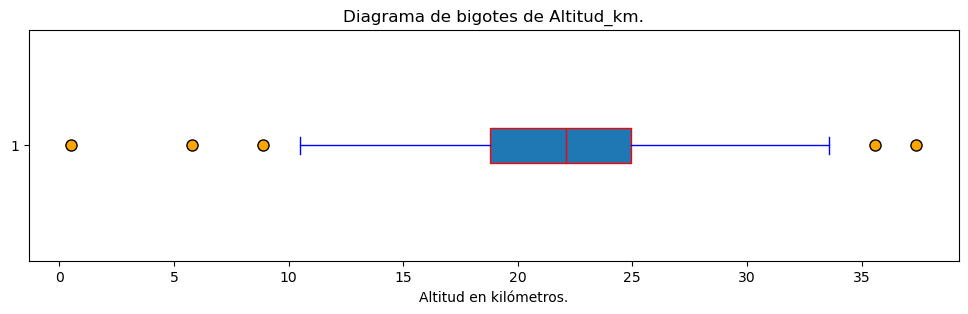

In [42]:
# Filtra el DataFrame para eliminar el outlier de Altitud_km de 150 km
print("Número de registros antes del filtrado:", df.ID_Registro.size)
df = df[df.Altitud_km != 150]   # Se aplica una máscara booleana al DataFrame
print("Número de registros después del filtrado:", df.ID_Registro.size)

# Vuelve a mostrar el diagrama de bigotes con el outlier eliminado
fig2, ax2 = plt.subplots(figsize=(12, 3))       # Marco de 12x3 pulgadas

ax2.boxplot(df.Altitud_km,                      # Boxplot de Altitud_km
            vert=False,                         # Horizontal
            patch_artist=True,                  # Interior de la caja IQR azul
            boxprops=dict(color='red'),         # Bordes de la caja IQR rojos
            medianprops=dict(color='red'),      # Mediana roja
            whiskerprops=dict(color='blue'),    # Bigotes azules
            capprops=dict(color='blue'),        # Extremos de los bigotes azules
            flierprops=dict(markerfacecolor='orange', markersize=8))    # Estilo de los outliers

plt.title("Diagrama de bigotes de Altitud_km.")
plt.xlabel("Altitud en kilómetros.")

plt.show()

Como este outlier distorsionaba enormemente la distribución, se vuelve a calcular la asimetría y curtosis.

In [43]:
# Calcula la asimetría y curtosis de Altitud_km tras la limpieza
asimetria_altitud = df.Altitud_km.skew()
curtosis_altitud = df.Altitud_km.kurt()
print("Asimetría de Altitud_km:", asimetria_altitud)
print("Curtosis de Altitud_km:", curtosis_altitud)

Asimetría de Altitud_km: -0.09285130155067207
Curtosis de Altitud_km: 0.8078177922960141


Ahora la muestra es bastante **simétrica**, acercando mucho la media a la mediana. Además la curtosis indica una **forma leptocúrtica mucho menos aguda**, cercana a un valor normal.

- **Nota importante**: La función kurt() de Pandas no calcula por defecto el valor de curtosis, sino el **exceso de curtosis de Fisher**, cuyo valor para una distribución normal es 0. (en la definición de Pearson el valor normal es 3).

[Fuente 1](https://www.datacamp.com/es/tutorial/understanding-skewness-and-kurtosis)

[Fuente 2](https://pythontic.com/pandas/series-computations/kurtosis)

## Fase 3: Identificar Cómplices (Análisis de Relaciones)
### 7. Matriz de Correlación Inicial:
Genera un mapa de calor (heatmap) con las variables numéricas originales para identificar qué factores varían juntos (ej. Viento vs. Maniobra).

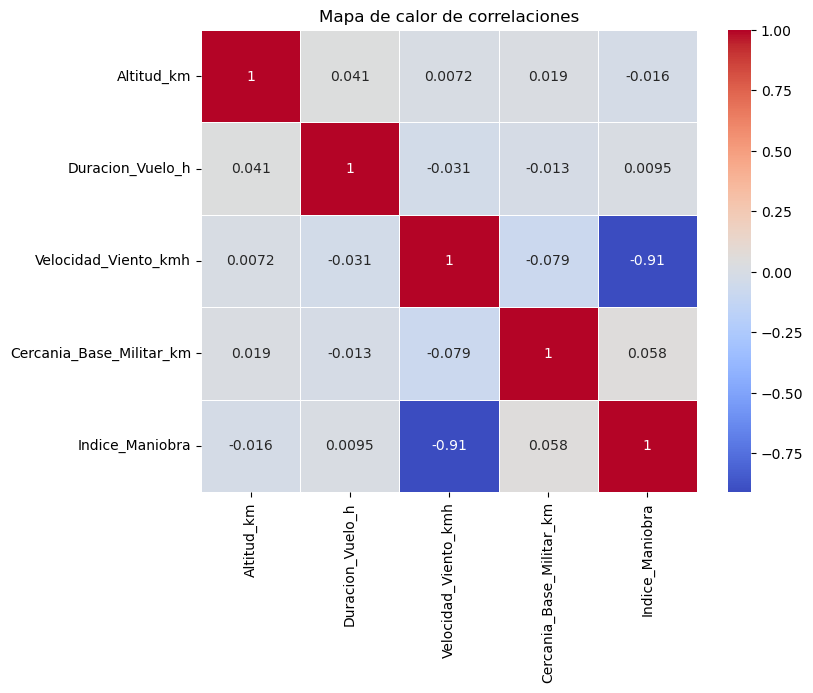

In [44]:
# Crea la matriz de correlación
corr_matrix = df.corr(numeric_only=True)    # Sólo se aplica a columnas numéricas

# Genera un mapa de calor de correlaciones
plt.figure(figsize=(8, 6))      # Marco de 8x6 pulgadas
sns.heatmap(corr_matrix,        # Mapa de calor generado con Seaborn
            annot=True,         # Muestra el valor (coef. de Pearson) en cada celda
            cmap='coolwarm',    # Mapea los valores a tonos azules (-) y rojos (+)
            linewidths=0.5)     # Ancho de las líneas de separación de celdas

plt.title("Mapa de calor de correlaciones")

plt.show()

A partir de un valor absoluto superior a 0.75 se intuye correlación lineal entre dos variables. Por tanto se observa una correlación inversa entre Velocidad_Viento_Kmh y Indice_Maniobra (a más viento, menos capacidad de maniobrar). Para interpretar esta relación hay que tener en cuenta que **los aerostatos maniobran cambiando de altitud para aprovechar distintas masas de aire con distintas direcciones, por lo que si el viento es más intenso se reduce la posibilidad de controlar la dirección del aerostato.**

### 8. Ingeniería de Características:
Crea un nuevo indicador llamado Indice_Riesgo combinando la duración del vuelo y la cercanía a bases militares mediante la fórmula:
$$\text{Índice\_Riesgo} = \frac{\text{Duración\_Vuelo\_h}}{\text{Cercanía\_Base\_Militar\_km} + 1}$$

In [45]:
# Genera una nueva variable 'Indice_Riesgo' siguiendo la fórmula
df["Indice_Riesgo"] = df.Duracion_Vuelo_h / (df.Cercania_Base_Militar_km + 1)

# Se redondean los valores para hacerlos más legibles
df.Indice_Riesgo = df.Indice_Riesgo.round(2)

display(df.head())  # Comprueba que se ha creado la nueva variable

,ID_Registro,Pais_Origen,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Tecnologia_Detectada,Cercania_Base_Militar_km,Fecha_Avistamiento,Indice_Maniobra,Indice_Riesgo
1,REG-1001,Desconocido,0.50,10.4,94.1,Inteligencia de Señales,103.66,2023-01-31,21.20,0.10
2,REG-1002,EE.UU.,25.24,5000.0,39.2,Vigilancia Radar,34.02,2023-01-31,63.00,142.78
3,REG-1003,China,29.62,23.0,12.3,Meteorológico,60.58,2023-01-02,96.11,0.37
4,REG-1004,Rusia,20.83,26.7,19.0,Meteorológico,246.80,2023-02-06,101.54,0.11
5,REG-1005,EE.UU.,20.83,41.5,116.5,Inteligencia de Señales,7.05,2023-01-17,22.01,5.16


### 9. Clasificación Estratégica:
Utiliza pd.cut() para crear la variable categórica Nivel_Alerta (Bajo, Moderado, Crítico) basada en el índice anterior.

In [46]:
# Para dividir las entradas en 3 partes del mismo tamaño se calculan los percentiles 33 y 66
indice_riesgo_perc33 = df.Indice_Riesgo.quantile(.33)
indice_riesgo_perc66 = df.Indice_Riesgo.quantile(.66)

# Se registra también el valor máximo
indice_riesgo_max = df.Indice_Riesgo.max()

# Se aplica cut() para discretizar el riesgo en 3 categorías y se crea la nueva variable 'Nivel_Alerta'
# Documentación del método pd.cut(): https://pandas.pydata.org/docs/reference/api/pandas.cut.html#pandas.cut
intervalos = [0, indice_riesgo_perc33, indice_riesgo_perc66, indice_riesgo_max]
etiquetas = ['Bajo', 'Moderado', 'Crítico']
df['Nivel_Alerta'] = pd.cut(df.Indice_Riesgo, intervalos, labels=etiquetas)

display(df.head())  # Comprueba que se ha creado la nueva variable

,ID_Registro,Pais_Origen,Altitud_km,Duracion_Vuelo_h,Velocidad_Viento_kmh,Tecnologia_Detectada,Cercania_Base_Militar_km,Fecha_Avistamiento,Indice_Maniobra,Indice_Riesgo,Nivel_Alerta
1,REG-1001,Desconocido,0.50,10.4,94.1,Inteligencia de Señales,103.66,2023-01-31,21.20,0.10,Bajo
2,REG-1002,EE.UU.,25.24,5000.0,39.2,Vigilancia Radar,34.02,2023-01-31,63.00,142.78,Crítico
3,REG-1003,China,29.62,23.0,12.3,Meteorológico,60.58,2023-01-02,96.11,0.37,Bajo
4,REG-1004,Rusia,20.83,26.7,19.0,Meteorológico,246.80,2023-02-06,101.54,0.11,Bajo
5,REG-1005,EE.UU.,20.83,41.5,116.5,Inteligencia de Señales,7.05,2023-01-17,22.01,5.16,Crítico


La decisión de utilizar percentiles para categorizar en 3 niveles de alerta se basa en que **no hay una magnitud predefinida para esta categorización. Por tanto se dividen los registros en 3 partes iguales.**

### 10. Re-planteamiento de la Matriz (Paso Crítico):
Vuelve a generar la matriz de correlación incluyendo el nuevo Indice_Riesgo. Analiza si esta nueva variable tiene mayor relación con otras que las variables originales por separado.

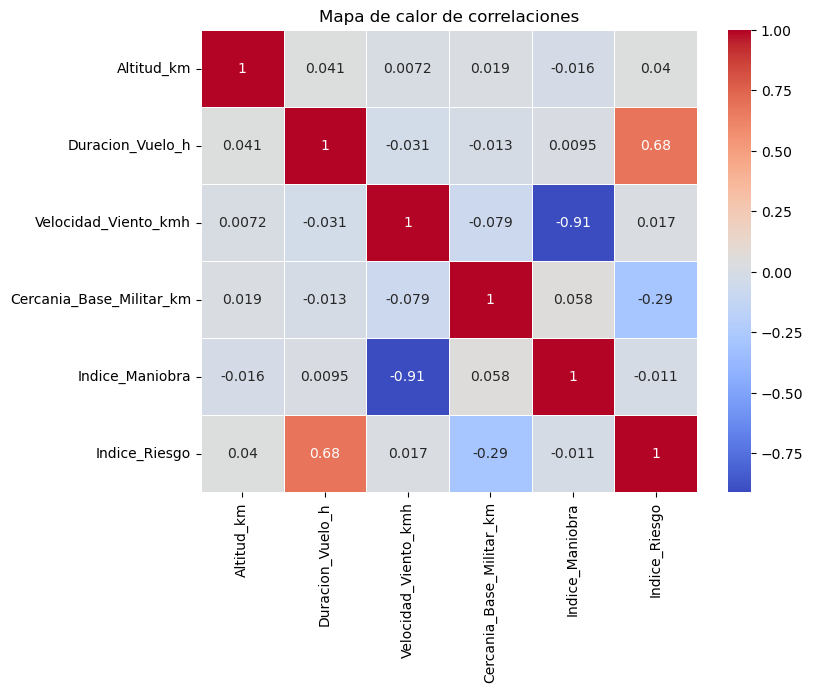

In [47]:
# Crea la matriz de correlación
corr_matrix = df.corr(numeric_only=True)    # Sólo se aplica a columnas numéricas

# Genera un mapa de calor de correlaciones
plt.figure(figsize=(8, 6))      # Marco de 8x6 pulgadas
sns.heatmap(corr_matrix,        # Mapa de calor generado con Seaborn
            annot=True,         # Muestra el valor (coef. de Pearson) en cada celda
            cmap='coolwarm',    # Mapea los valores a tonos azules (-) y rojos (+)
            linewidths=0.5)     # Ancho de las líneas de separación de celdas

plt.title("Mapa de calor de correlaciones")

plt.show()

Se observa correlación entre el índice de riesgo, la duración del vuelo y la cercanía a la base militar. Es lógico ya que para calcular el riesgo se ha aplicado la fórmula:
$$\text{Índice\_Riesgo} = \frac{\text{Duración\_Vuelo\_h}}{\text{Cercanía\_Base\_Militar\_km} + 1}$$
donde el índice es directamente proporcional a la duración del vuelo e inversamente proporcional a la cercanía a la base militar. Como ya se sabe el motivo de estas correlaciones no tiene sentido investigarlas.

## Fase 4: Modelado Predictivo
### 11. Regresión Lineal Simple:
Entrena un modelo para predecir el Indice_Maniobra (Variable Y) basándote en la Velocidad_Viento_kmh (Variable X).

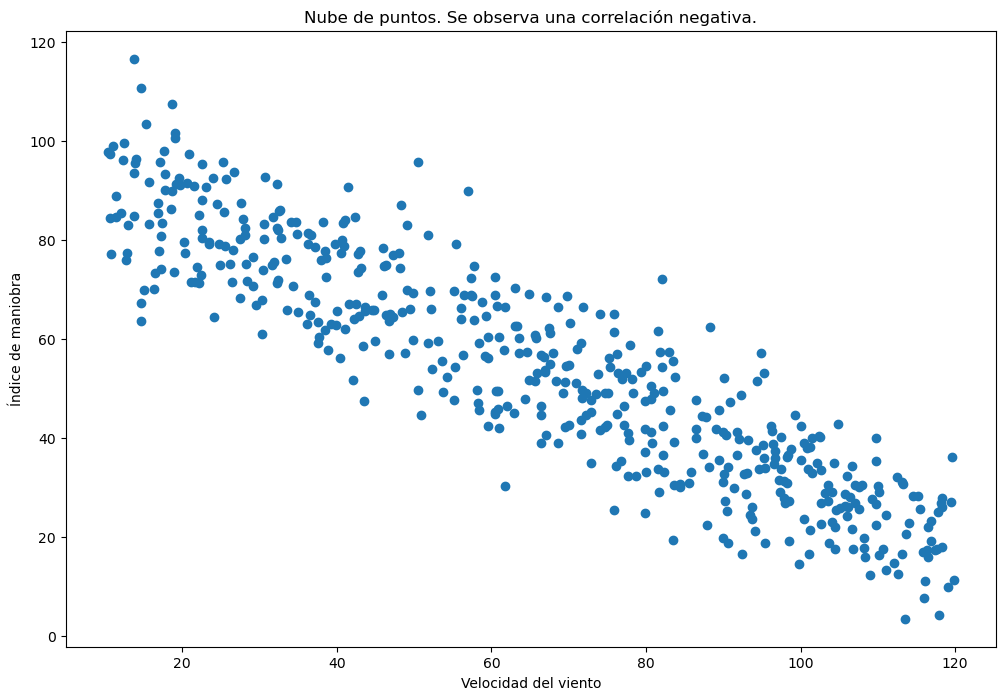

In [48]:
fig3, ax3 = plt.subplots(figsize=(12, 8))
ax3.scatter(df.Velocidad_Viento_kmh,    # Variable independiente X
            df.Indice_Maniobra)         # Variable dependiente Y

plt.xlabel("Velocidad del viento")
plt.ylabel("Índice de maniobra")
plt.title("Nube de puntos. Se observa una correlación negativa.")

plt.show()

Partiendo de que el coeficiente de correlación de Pearson entre la velocidad del viento y el índice de maniobra es de -0.91 (por encima de 0.75 en valores absolutos se intuye correlación), se genera una nube de puntos para visualizar la correlación entre el viento y la maniobrabilidad de los aerostatos. La velocidad del viento se considera la variable independiente (X) y la maniobrabilidad la dependiente (Y), ya que interesa saber qué maniobra tenemos según velocidad del viento.
Observando la nube de puntos se intuye una relación lineal. Aplicando el modelo de regresión lineal se tratará de encontrar la línea recta que sea más próxima al conjunto de todos los puntos.

In [49]:
# Prepara los datos para el entrenamiento
x = df.Velocidad_Viento_kmh.values.reshape((-1, 1)) # con reshape() se forma una matriz, necesaria para el entrenamiento
y = df.Indice_Maniobra

# Crea el modelo de regresión lineal
modelo = LinearRegression().fit(x, y)

# Del modelo se extrae la pendiente (m) y el intercepto (b)
m = modelo.coef_[0]
b = modelo.intercept_
print("Pendiente de la recta:", m)
print("Intercepto (valor de y para x = 0):", b)

Pendiente de la recta: -0.6719047303721917
Intercepto (valor de y para x = 0): 98.42150552088351


### 12. Interpretación de Resultados:
   - Muestra la ecuación de la recta ($Y = mx + b$).
   - Interpreta la Bondad de Ajuste ($R^2$). Un valor cercano a 0.82 indica una alta fiabilidad.

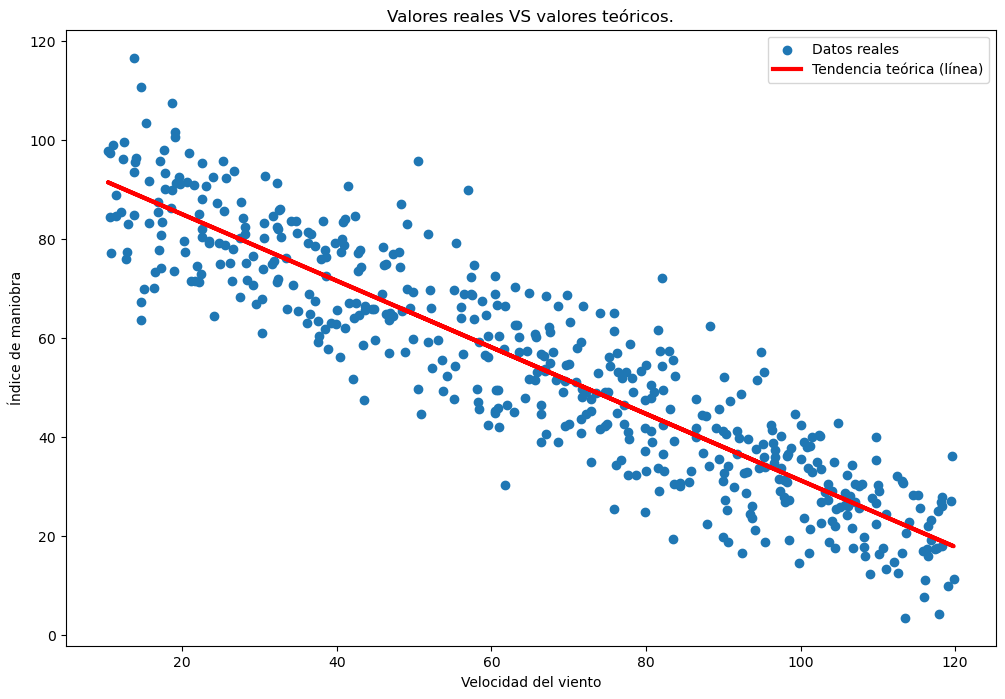

In [50]:
# Aplica la pendiente y el intercepto a la fórmula de la recta para trazar la recta
x_linea = np.sort(x)    # Ordena todos los valores de x
y_linea = m*x + b       # Calcula el valor de Y para cada valor de X (fórmula de la recta)

fig4, ax4 = plt.subplots(figsize=(12, 8))

# Nube de puntos
ax4.scatter(df.Velocidad_Viento_kmh,    # Variable independiente X
            df.Indice_Maniobra,         # Variable dependiente Y
            label='Datos reales')

# Línea teórica
ax4.plot(x_linea, y_linea, color='red', linewidth=3, label='Tendencia teórica (línea)')

plt.xlabel("Velocidad del viento")
plt.ylabel("Índice de maniobra")
plt.title("Valores reales VS valores teóricos.")
plt.legend()    # Leyenda

plt.show()

La bondad del ajuste es el porcentaje de fiabilidad. Un valor de 0.82 significa que **el 82% de la maniobrabilidad se explica con la velocidad del viento.**

In [51]:
r2 = modelo.score(x, y)
print(f"Coeficiente de determinación (bondad): {r2:.2f}")

Coeficiente de determinación (bondad): 0.83


### 13. Validación del Modelo:
Genera un histograma de residuos. Explica si el modelo es fiable basándote en si los residuos siguen una distribución normal centrada en cero.

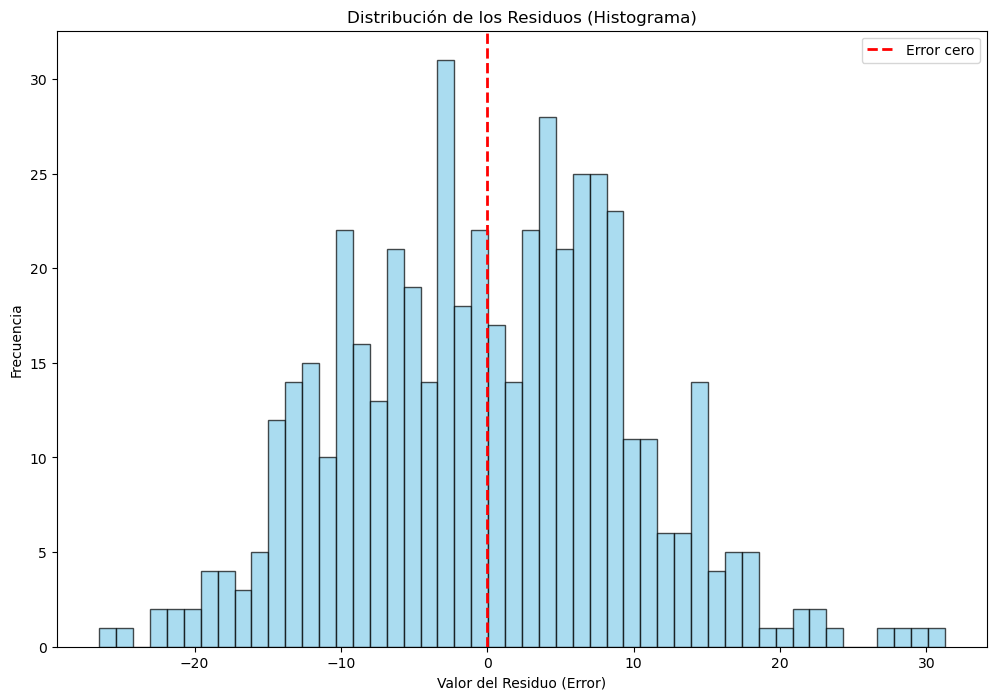

In [52]:
# Calcula los valores teóricos de maniobrabilidad para cada valor real de velocidad del viento
y_teorica = m*df.Velocidad_Viento_kmh + b

# Calcula los residuos (diferencias entre los valores de maniobrabilidad reales y los teóricos)
residuos = df.Indice_Maniobra - y_teorica

# Genera el histograma de residuos
fig5, ax5 = plt.subplots(figsize=(12, 8))

ax5.hist(residuos, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Añade una línea vertical en el 0 (ausencia de error)
ax5.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error cero')

ax5.set_xlabel("Valor del Residuo (Error)")
ax5.set_ylabel("Frecuencia")
ax5.set_title("Distribución de los Residuos (Histograma)")
ax5.legend()

plt.show()

**La forma del histograma se asemeja a una distribución normal (es similar a una campana de Gauss) por lo que se puede confirmar que el modelo de regresión es fiable.**